# Part A: Building point-based validation metrics

## Objective
Given a WRF grid cell and its nearest Fire Emergency New Zealand weather station,
build validation toolkit to calculate validation metrics illustrated in the reading material
handout. The coefficient of determination, root mean square error, and the index of
agreement. The meteorological variables we will be validating for are wind speed, air
temperature, and relative humidity. Produce a well commented (using markdown and in-cell
comments) Jupyter notebook sections that full fill the following requirements.
1. For your observational stations you will use two FENZ weather station locations.
a. Godley Head (a coastal site in Canterbury with complex topography)
b. Darfield, Forest Plains (a flat terrain site inland Canterbury)
2. Use a week of your choice in January and a week in July to extract the time series from a WRF
grid point and the nearest FENZ weather station. Your choice of the week and year should
ensure data availability from the weather station (real data will have data availability issues,
double check your choice)
3. Write code that calculates the RMSE, IOA, and R-square validation metrics. Your n (refer to the
reading material document) should be the total number of observations in the week period.
Report your results using a table.
4. Produce time series plots of observed and modelled meteorological variables at both
locations. Your plots should demonstrate a one to one comparison and their objective is to
visualize the trend and biases while investigating the actual data without summary error
statistics yet. Describe and discuss your results.
5. Produce scatter plots of observed and modelled meteorological variables for both locations.
Add a linear trend line that best fits the data points and report the equation of the line. For
reference this is similar to the green lines in the case studies presented in the reading material
handout. Describe and discuss your results.

* One weather station will probably perform better than the other
* Godley Head was chosen because of its complex terrain
* The weather model has 4km resolution but the GH headland is only 1.3km across so the resolution probably won't accurately represent it
* Wind Atlas - resource for 1km wind model


NEW Stations:

Southbridge 02139bfc0beb28e0229b756e 172.25856, -43.84945
Glentanner b1ccc6ead3273d01c94501bd  170.12862, -43.91498

### Import libraries

In [1]:
pip install HydroErr

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
from tethysts import Tethys # import the Tethys class
import tethys_helper
import os
from time import time
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from pathlib import Path

### Define constants

In [65]:
OWNER = "FENZ"

SOUTHBRIDGE = {
    'filename': "southbridge_aws.nc",
    'station_id': "02139bfc0beb28e0229b756e",
    'location': { 'lon': 172.25856, 'lat': -43.84945 }
}
GLENTANNER = {
    'filename': "glentanner_aws.nc",
    'station_id': "b1ccc6ead3273d01c94501bd",
    'location': { 'lon': 170.12862, 'lat': -43.91498 }
}
STATIONS = {
    'Southbridge': SOUTHBRIDGE,
    'Glentanner': GLENTANNER,
}

PARAMETERS = ['wind_speed', 'relative_humidity', 'temperature' ]
VARIABLES = ['wind_speed', 'relative_humidity', 'air_temperature' ]

DATE_RANGES = [
  { 'start_date': "2020-01-06", 'end_date': "2020-01-13" },
  { 'start_date': "2019-07-10", 'end_date': "2019-07-17" },
]

AXIS_LABEL_FONT_SIZE = 8
TITLE_FONT_SIZE = 12

## Define some utility functions

`calc_wind_speed` calculates overall wind speed from the North-South and the East-West wind speed values.

In [4]:
def calc_wind_speed(u, v):
  usqr = u ** 2
  vsqr = u ** 2

  # Wind speed calculation is the square root of the sum of the squares
  return np.sqrt(usqr + vsqr)

`plot_model_vs_observations` creates a graph of the predicted and observed data for one variable over one time period

In [12]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()

In [58]:
def to_nz_time(ds):
    months = ds['time'].dt.month
    is_summer_time = (months >= 4) & (months <= 9)

    shift_12h = np.timedelta64(12, 'h')
    shift_13h = np.timedelta64(13, 'h')

    nz_offsets = np.where(is_summer_time, shift_12h, shift_13h)

    local_times = ds['time'].values + nz_offsets
    ds = ds.drop_vars('time')
    ds = ds.assign_coords(time=(['time'], local_times))
    
    return ds

## Q1: Loading the data

> For your observational stations you will use two FENZ weather station locations. The data files
> are in the assignment dropbox (glentanner_aws.nc, and southbridge_aws.nc)
> a. Glentanner (a mountainous site in Mackenzie)
> b. Southbridge (a flat terrain site in Canterbury

This code loads the two provided data files into an XArray dataset, and stores it in the STATIONS dictionary, for use by subsequent code cells.

In [67]:
base_dir = Path("/home/UOCNT/tco111/GISC405")

for k_ix, key in enumerate(STATIONS.keys()):
    stn = STATIONS[key]
    file_path = base_dir / stn["filename"]
    dataset = xr.open_dataset(file_path)
    stn['dataset'] = dataset

In [22]:
stn = STATIONS['Glentanner']
to_nz_time(stn['dataset'])

<xarray.DataArray 'month' (time: 81245)> Size: 650kB
array([3, 3, 3, ..., 8, 8, 8], shape=(81245,))
Coordinates:
  * time     (time) datetime64[ns] 650kB 2017-03-15 ... 2026-08-09T18:00:00
Attributes:
    DIMENSION_LABELS:  time
    dtype:             int64
    dtype_decoded:     datetime64[s]


## Q2: Extract time series for January and July

> Use a week of your choice in January and a week in July to extract the time series from a WRF
> grid point and the nearest FENZ weather station.

The function 'extract_model_series' loads a time slice from the WRF data for a given data type (i.e. 'RH' or 'T') for the given lat/lon location.

In [7]:
def extract_model_series(data_type, start_date, end_date, location, height=2):
    date_obj = datetime.strptime(start_date, "%Y-%m-%d")
    dataset = xr.open_dataset(f"/mnt/data/MetService_WRF/{data_type}_{date_obj.year}{date_obj.month:02d}01000000.nc")
    time_slice = dataset.sel(time=slice(start_date, end_date))
    return time_slice[data_type].sel(height=height, lat=location['lat'], lon=location['lon'], method="nearest")

### Sanity check on time zones

Both data sets are in UTC. To get accurate plots I added the `to_nz_time` utility function above to convert the data to local time. The code below demonstrates by plotting the temperature for a 2 day period both before and after time zone adjustment. The shapes are the same but note that the x-axis on the second plot is shifted.

['2020-01-06T00:00:00.000000000' '2020-01-06T01:00:00.000000000'
 '2020-01-06T02:00:00.000000000']


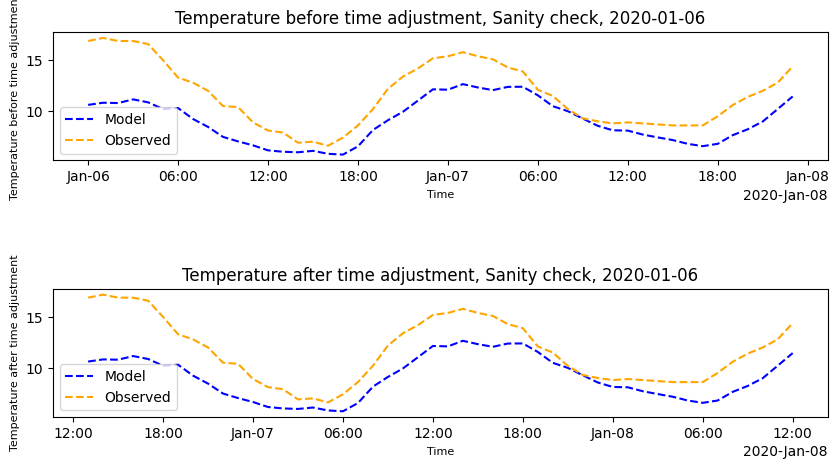

In [72]:
# Sanity check: are both datasets in the same time zone?
stn = STATIONS['Glentanner']
d = { 'start_date': "2020-01-06", 'end_date': "2020-01-07" }
obs = np.squeeze(stn['dataset'].temperature.sel(time=slice(d['start_date'], d['end_date'])))
pred = extract_model_series('T', d['start_date'], d['end_date'], stn['location'])

# Convert Kelvin to Celsius
pred = pred - 273.15

fig, ax = plt.subplots(2, 1, figsize=(10,5))

print(pred['time'].values[:3])

# The first plot shows that the data is in UTC for both datasets - the temperature peaks at just after midnight rather than just after midday.
plot_model_vs_observations(pred, obs, 'Sanity check', d["start_date"], 'Temperature before time adjustment', ax[0])

pred_2 = to_nz_time(pred)
obs_2 = to_nz_time(obs)

# The second plot shows that the datasets are now in local NZ time with temperature peacking at midday.
plot_model_vs_observations(pred_2, obs_2, 'Sanity check', d["start_date"], 'Temperature after time adjustment', ax[1])

plt.subplots_adjust(hspace=1.0)
plt.show()



## Q3: Calculate RMSE, R2 and IOA

> Write code that calculates the RMSE, IOA, and R-square validation metrics. Your n (refer to the
> reading material document) should be the total number of observations in the week period.
> Report your results using a table

The code below makes use of the HydroErr package for calculation of metrics, and Pandas to create a DataFrame for conveniently displaying the data in a table.


In [68]:
import pandas as pd
import HydroErr

# Accumulators for the three variables
rh = []
t = []
ws = []

# For each location
for k_ix, key in enumerate(STATIONS.keys()):
  stn = STATIONS[key]

  # Create a relative humidity row
  rh_row = [ key, 'RH' ]
  for d in DATE_RANGES:
      rh_obs = np.squeeze(stn['dataset'].relative_humidity.sel(time=slice(d['start_date'], d['end_date'])))
      rh_pred = extract_model_series('RH', d['start_date'], d['end_date'], stn['location'])
      rh_obs=to_nz_time(rh_obs)
      rh_pred=to_nz_time(rh_pred)
      assert len(rh_pred.values) == len(rh_obs.values)

      rh_row.append(HydroErr.HydroErr.rmse(rh_pred.values, rh_obs.values))
      rh_row.append(HydroErr.HydroErr.d(rh_pred.values, rh_obs.values))
      rh_row.append(HydroErr.HydroErr.r_squared(rh_pred.values, rh_obs.values))
  rh.append(rh_row)

  # Create a temperature row
  t_row = [ key, 'T' ]
  for d in DATE_RANGES:
      t_obs = np.squeeze(stn['dataset'].temperature.sel(time=slice(d['start_date'], d['end_date'])))
      t_pred = extract_model_series('T', d['start_date'], d['end_date'], stn['location'])
      # Convert Kelvin to Celsius
      t_pred = t_pred - 273.15
      t_obs = to_nz_time(t_obs)
      t_pred = to_nz_time(t_pred)
      assert len(t_pred.values) == len(t_obs.values)

      t_row.append(HydroErr.HydroErr.rmse(t_pred.values, t_obs.values))
      t_row.append(HydroErr.HydroErr.d(t_pred.values, t_obs.values))
      t_row.append(HydroErr.HydroErr.r_squared(rh_pred.values, t_obs.values))
  t.append(t_row)

  # Create a wind speed row
  ws_row = [ key, 'WS' ]
  for d in DATE_RANGES:
      ws_obs = np.squeeze(stn['dataset'].wind_speed.sel(time=slice(d['start_date'], d['end_date'])))
      u_pred = extract_model_series('U', d['start_date'], d['end_date'], stn['location'])
      v_pred = extract_model_series('V', d['start_date'], d['end_date'], stn['location'])
      ws_pred = calc_wind_speed(u_pred, v_pred)
      ws_obs = to_nz_time(ws_obs)
      ws_pred = to_nz_time(ws_pred)
      assert len(ws_pred.values) == len(ws_obs.values)
      ws_row.append(HydroErr.HydroErr.rmse(ws_pred.values,ws_obs.values))
      ws_row.append(HydroErr.HydroErr.d(ws_pred.values, ws_obs.values))
      ws_row.append(HydroErr.HydroErr.r_squared(ws_pred.values, ws_obs.values))
  ws.append(ws_row)

pd.DataFrame(rh + t + ws,
             columns=["Location", "Variable", "RMSE Jan", "IOA Jan", "R SQUARED Jan", "RMSE Jul", "IOA Jul", "R SQUARED Jul"])


,Location,Variable,RMSE Jan,IOA Jan,R SQUARED Jan,RMSE Jul,IOA Jul,R SQUARED Jul
0,Southbridge,RH,16.804337,0.759246,0.634191,9.748263,0.773061,0.431100
1,Glentanner,RH,17.588012,0.677318,0.232172,15.235615,0.605878,0.262487
2,Southbridge,T,2.483901,0.928219,0.155952,2.110919,0.914016,0.368997
3,Glentanner,T,3.294381,0.789413,0.023369,2.183654,0.797937,0.061655
4,Southbridge,WS,2.548940,0.704516,0.280038,2.090894,0.461624,0.013732
5,Glentanner,WS,3.169480,0.653849,0.207753,2.058047,0.692980,0.234140


 ## Q4: Visualise the data

> Produce time series plots of observed and modelled meteorological variables at both
> locations. Your plots should demonstrate a one to one comparison and their objective is to
> visualize the trend and biases while investiga

The below function defines a helper to plot both the model and observation data for a given parameter and date range.

In [9]:
def plot_model_vs_observations(model_data, obs_data, key, month, data_type, ax):
    model_data.plot(ax=ax, linestyle="dashed",color="blue",label="Model")
    obs_data.plot(ax=ax, linestyle="dashed",color="orange",label="Observed")
    ax.set_xlabel("Time", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_ylabel(data_type, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_title(f"{data_type}, {key}, {month}")
    ax.legend()
    

Generate the comparison plots. Chosen weeks are the week starting Jan 6th 2020, and the week starting July 10th 2019.

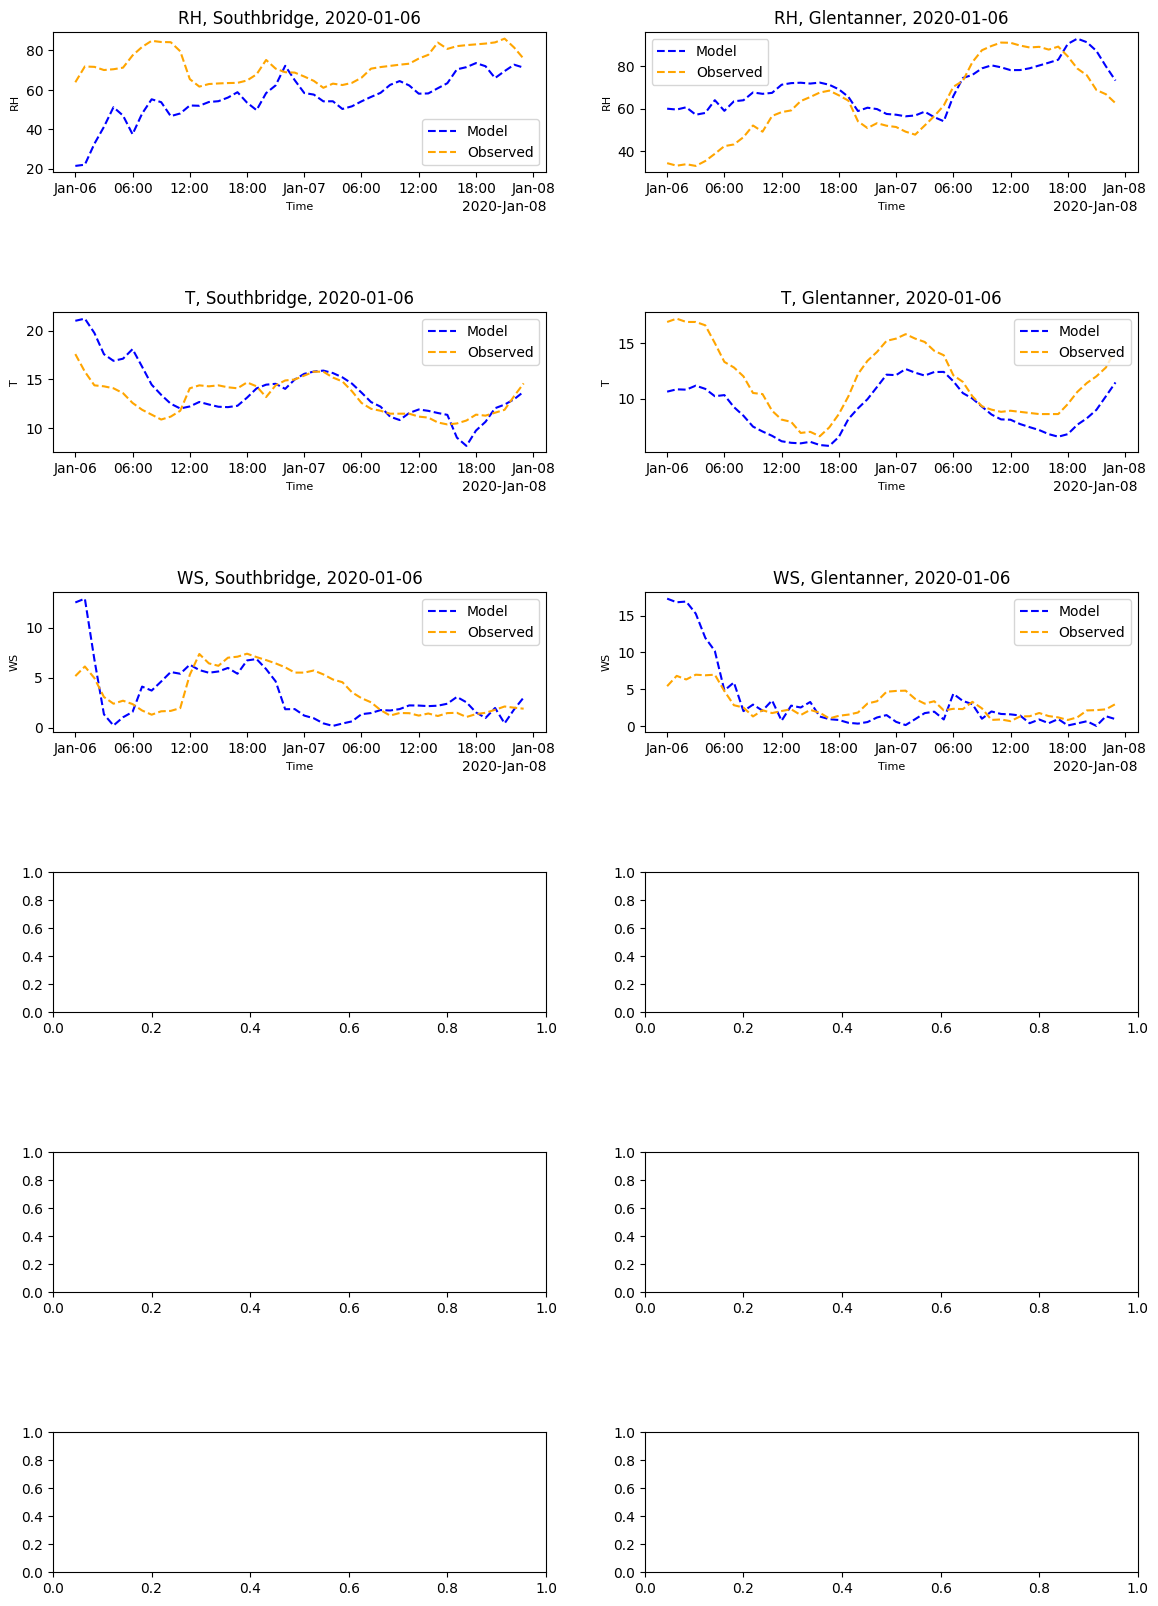

In [10]:
fig, axs = plt.subplots(6, 2, figsize=(14,20))

ax_y = 0
for d_ix, date_range in enumerate(DATE_RANGES):
    start_date = date_range['start_date']
    end_date = date_range['end_date']

    ax_y = d_ix * 3
    
    for k_ix, key in enumerate(STATIONS.keys()):
      stn = STATIONS[key]
      dataset_observations = stn['dataset']
      time_slice_observed = dataset_observations.sel(time=slice(start_date, end_date))
    
      rh_model = extract_model_series('RH', start_date, end_date, stn['location'])
      rh_obs = time_slice_observed.relative_humidity
      plot_model_vs_observations(rh_model, rh_obs, key, start_date, 'RH', axs[ax_y+0][k_ix])
    
      # Model temperatures are in kelvin so need to be converted
      t_model = extract_model_series('T', start_date, end_date, stn['location'])
      t_model = t_model - 273.15
      t_obs = time_slice_observed.temperature
      plot_model_vs_observations(t_model, t_obs, key, start_date, 'T', axs[ax_y+1][k_ix])
    
      # Wind speed in the WRF data is in two directions and need to be combined
      u_model = extract_model_series('U', start_date, end_date, stn['location'])
      v_model = extract_model_series('V', start_date, end_date, stn['location'])
      ws_model = calc_wind_speed(u_model, v_model)
      ws_obs = time_slice_observed.wind_speed
      
      plot_model_vs_observations(ws_model, ws_obs, key, start_date, 'WS', axs[ax_y+2][k_ix])

plt.subplots_adjust(hspace=1.0)
plt.show()

## Discussion of the above results

### Southbridge

Relative humidity:
IoA is fairly high for both weeks (0.75, 0.77). You can confirm this visually in that the graph shapes track each other quite closely without any large outliers.
RMSE fairly high (16%) in January, which you can see on the graph in that the observed line is sitting higher than the predicted line all the way across the time period. IoA is quite high though, since there were no big spikes in the difference.
R squared is better in January (0.63) than July (0.43) where you can see the strong dip in the model on July 15. January's Rsquared would have been better if not for the gaps between model & prediction around the 6th, 10th, and 11th.

Temperature:

IoA is high in both periods (in the 90s)
RMSE is pretty low - about 2 degrees for both periods.
But Rsquared is very low! TODO why?

Wind speed:
IoA for wind speed was much higher for January than for July - on July 13th 2019 there was a strong wnd watch issued by met service. a severe weather system moved through Canterbury on the 13th-14th. This would explain the IoA for that period being only 46%.  IoA is sensitive to large outliers or extreme weather events. You can see the wind speed peak in the observed line on the July graph.
RMSE is around 2 m/s for both periods - averaging errors accross the time period covers up the outlier in July. 
R squared is low for both periods, but very low (0.01) for July. R squared focuses on trend matching, so the wind event in July would affect it strongly.

### Glentanner

RH:
Visually both periods totally different between model & observations! The observed data is much more variable than the predicted data. 
17% and 15% RMSE which isn't that much higher than Southbridge's RH values.
IoAs in the 0.6's, but R Squared really low (0.23, 0.26). 




## Q5: Scatter plots

> Produce scatter plots of observed and modelled meteorological variables for both locations.
> Add a linear trend line that best fits the data points and report the equation of the line. For
> reference this is similar to the green lines in the case studies presented in the reading material
> handout. Describe and discuss your results.

# Part B